In [1]:
cd /Users/safishajjouz/GitHub/QuantitativePortfolioManagement/

/Users/safishajjouz/GitHub/QuantitativePortfolioManagement


In [3]:
import pandas as pd

from myPortfolioManagement.myData import get_stock_prices
from myPortfolioManagement.myPortfolioOptimisation import equal_weight_portfolio
from myPortfolioManagement.myReturns import calculate_portfolio_returns
from myPortfolioManagement.myPerformanceAnalytics import performance_overview
import monthly_returns_heatmap as mrh
import quantstats as qs
import warnings
warnings.filterwarnings("ignore")


def style_df(df_):
    def style_negative(v, props=''):
        return props if v < 0 else None

    styles = [
        dict(selector="tr:hover",
             props=[("background", "#D6EEEE")]),
        dict(selector="th", props=[("color", "#fff"),
                                   ("border", "0px solid #eee"),
                                   ("padding", "1px 10px"),
                                   ("border-collapse", "collapse"),
                                   ("background", "#2C3E50"),
                                   ("font-size", "12px")
                                   ]),
        dict(selector="td", props=[("border", "1px solid #EAECEE"),
                                   ("padding", "5px 10px"),
                                   ("border-collapse", "collapse"),
                                   ("font-size", "12px")
                                   ]),
        dict(selector="table", props=[
            ("font-family", 'sans-serif'),
            ("margin", "25px auto"),
            ("border-collapse", "collapse"),
            ("border", "1px solid #eee"),
            ("border-bottom", "2px solid #00cccc"),
        ]),
        dict(selector="caption", props=[("caption-side", "bottom")]),
        dict(selector="tr:nth-child(even)", props=[
            ("background-color", "#fff"),
        ]),
    ]

    x = df_.style.applymap(style_negative, props='color:red;') \
        .format(formatter="{:,.2f}%".format, na_rep='-').set_table_styles(styles)

    return x


In [4]:
df_tickers = pd.read_csv('/Users/safishajjouz/PycharmProjects/myWatchlist/Data/myWatchlist_2023-04-02T19_00_58Z.csv')

df_tickers = df_tickers[['Name', 'Symbol', 'Currency']]
df_tickers.dropna(how='all', inplace=True)
df_tickers['Tickers'] = df_tickers["Symbol"].str.split(":", expand=True)[0]

tickers_usd = df_tickers[df_tickers['Currency'] == 'USD']['Tickers'].tolist()
tickers_London = df_tickers[df_tickers['Currency'] != 'USD']['Tickers'].tolist()
tickers_London = [x + '.L' for x in tickers_London]

tickers_London = ['NSRGY' if item == 'NESN.L' else item for item in tickers_London]  # Nestle
tickers_London = ['0P00012CU7.L' if item == 'LU1033663649.L' else item for item in
                  tickers_London]  # Fidelity Global tech
tickers_London = ['0P000023MW.L' if item == 'GB00B0CNH163.L' else item for item in tickers_London]  # Global Tech
tickers_London = ['0P0000KSP6.L' if item == 'GB00B59G4Q73.L' else item for item in tickers_London]  # Global Equity

drop_symbols = ['GB00BYVGKV59.L', 'LU0827889725.L', 'GB00B46KYQ57.L', 'GB00B87BSD02.L',
                'GB00B41YBW71.L', 'GB00B79LTQ12.L']

for x in drop_symbols:
    tickers_London.remove(x)

tickers = tickers_usd + tickers_London

df_stock_prices = get_stock_prices(yahoo_tickers=tickers, start_date='2012-01-01', wide_format=True, fix_data=True)
df_market_prices = get_stock_prices(yahoo_tickers=['^GSPC'], start_date='2012-01-01', wide_format=True, fix_data=True)


get_stock_prices took 6.184sec
get_stock_prices took 149.53ms


## My Stocks 

In [ ]:
col1 = [x.replace('.L', "") for x in tickers_London]
col1 = [x.replace('0P00012CU7', "LU1033663649") for x in col1]
col1 = [x.replace('0P000023MW', "GB00B0CNH163") for x in col1]
col1 = [x.replace('0P0000KSP6', "GB00B59G4Q73") for x in col1]
col1 = [x.replace('NSRGY', "NESN") for x in col1]

In [5]:
df_tickers[df_tickers['Tickers'].isin(col1 + tickers_usd)]

,Name,Symbol,Currency,Tickers
0,Abbvie Inc,ABBV:NYQ,USD,ABBV
1,Albemarle Corp,ALB:NYQ,USD,ALB
2,Allianz Technology Trust PLC,ATT:LSE,GBX,ATT
3,Amazon.com Inc,AMZN:NSQ,USD,AMZN
4,Apple Inc,AAPL:NSQ,USD,AAPL
6,BHP Group Ltd,BHP:NYQ,USD,BHP
9,BlackRock Throgmorton Trust plc,THRG:LSE,GBX,THRG
11,Carrier Global Corp,CARR:NYQ,USD,CARR
12,Cloudflare Inc,NET:NYQ,USD,NET
13,Costco Wholesale Corp,COST:NSQ,USD,COST


In [6]:
# construct a naive portfolio
returns = df_stock_prices.pct_change()
returns.dropna(how='all', inplace=True)

# portfolio returns
weights = equal_weight_portfolio(returns)
port_returns = calculate_portfolio_returns(returns, weights.index, weights['port_naive'])

# benchmark
ret_sp = df_market_prices.pct_change()

# total returns
ret = ret_sp.reset_index('Date').merge(port_returns.reset_index('Date')).set_index('Date')
ret.columns = ['Market', 'myPortfolio']



In [7]:
# rename the columns labels with month names
ret_monthly_port = mrh.get(port_returns, eoy=True)
ret_monthly_market = mrh.get(ret_sp, eoy=True)
months = ['Jan', 'Feb', 'March', 'April', 'May', 'June', 'July', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Total']
ret_monthly_port.columns = months
ret_monthly_market.columns = months

### Monthly Performance: Portfolio vs Market

In [8]:
style_df(ret_monthly_port*100)

,Jan,Feb,March,April,May,June,July,Aug,Sep,Oct,Nov,Dec,Total
Year,,,,,,,,,,,,,
2012,4.00%,3.46%,1.40%,-0.28%,-5.14%,2.09%,-0.56%,2.83%,1.70%,-0.92%,0.83%,2.04%,11.70%
2013,3.35%,2.27%,3.21%,1.61%,3.40%,-1.81%,4.83%,-0.02%,7.29%,1.83%,0.65%,1.43%,31.55%
2014,0.67%,5.91%,-0.83%,-1.52%,1.06%,1.88%,0.25%,4.15%,2.54%,1.71%,0.88%,-1.04%,16.55%
2015,-1.11%,5.55%,-0.99%,3.17%,2.72%,-2.53%,2.93%,-5.28%,-3.32%,5.32%,-0.38%,2.27%,7.97%
2016,-6.49%,0.70%,5.95%,4.05%,1.84%,2.30%,4.73%,0.63%,1.39%,-1.60%,0.73%,0.77%,15.42%
2017,6.59%,3.74%,1.28%,2.07%,4.01%,0.08%,2.68%,3.28%,2.63%,3.23%,4.05%,0.70%,40.09%
2018,4.80%,0.82%,-1.98%,2.10%,4.04%,1.81%,1.10%,3.67%,1.51%,-5.85%,1.62%,-6.47%,6.63%
2019,7.92%,6.03%,1.43%,3.28%,-3.39%,5.31%,3.61%,-1.01%,-1.68%,0.80%,6.93%,4.97%,39.15%
2020,5.02%,-0.33%,-5.74%,14.59%,11.09%,8.05%,8.82%,9.66%,0.48%,0.28%,14.91%,5.90%,98.57%


In [9]:
style_df(ret_monthly_market*100)

,Jan,Feb,March,April,May,June,July,Aug,Sep,Oct,Nov,Dec,Total
Year,,,,,,,,,,,,,
2012,2.77%,4.06%,3.13%,-0.75%,-6.27%,3.96%,1.26%,1.98%,2.42%,-1.98%,0.28%,0.71%,11.68%
2013,5.04%,1.11%,3.60%,1.81%,2.08%,-1.50%,4.95%,-3.13%,2.97%,4.46%,2.80%,2.36%,29.60%
2014,-3.56%,4.31%,0.69%,0.62%,2.10%,1.91%,-1.51%,3.77%,-1.55%,2.32%,2.45%,-0.42%,11.39%
2015,-3.10%,5.49%,-1.74%,0.85%,1.05%,-2.10%,1.97%,-6.26%,-2.64%,8.30%,0.05%,-1.75%,-0.73%
2016,-5.07%,-0.41%,6.60%,0.27%,1.53%,0.09%,3.56%,-0.12%,-0.12%,-1.94%,3.42%,1.82%,9.54%
2017,1.79%,3.72%,-0.04%,0.91%,1.16%,0.48%,1.93%,0.05%,1.93%,2.22%,2.81%,0.98%,19.42%
2018,5.62%,-3.89%,-2.69%,0.27%,2.16%,0.48%,3.60%,3.03%,0.43%,-6.94%,1.79%,-9.18%,-6.24%
2019,7.87%,2.97%,1.79%,3.93%,-6.58%,6.89%,1.31%,-1.81%,1.72%,2.04%,3.40%,2.86%,28.88%
2020,-0.16%,-8.41%,-12.51%,12.68%,4.53%,1.84%,5.51%,7.01%,-3.92%,-2.77%,10.75%,3.71%,16.26%


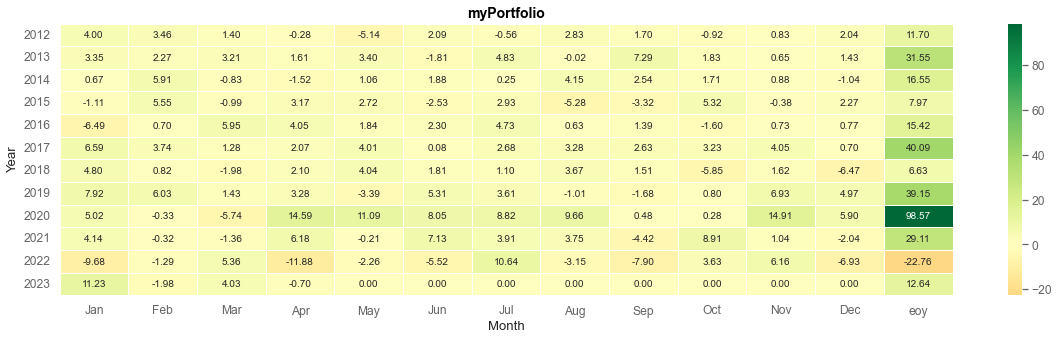

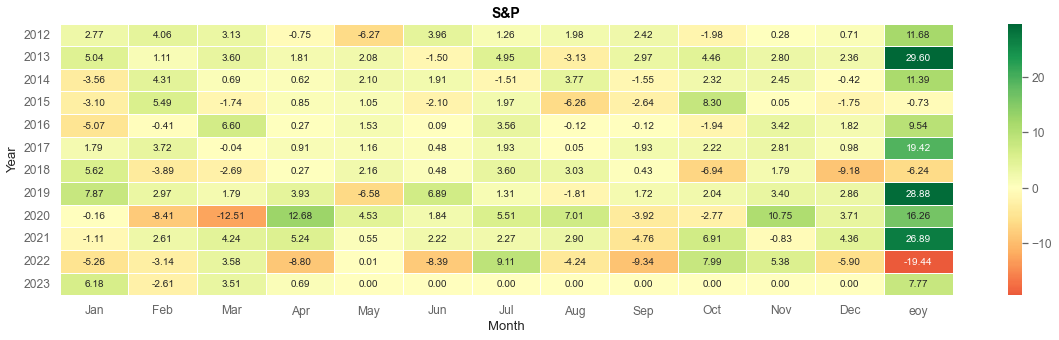

In [10]:
# plot monthly returns
mrh.plot(port_returns, eoy=True, title='myPortfolio', figsize = (20,5))
mrh.plot(ret_sp, eoy=True, title='S&P', figsize = (20,5))


## Yearly Performance

In [ ]:
# Yearly performance vs Market 
ret_sp_eoy = mrh.get(ret_sp, eoy=True)[['eoy']]
ret_sp_eoy.columns = ['Market']
ret_portfolio_eoy = mrh.get(port_returns, eoy=True)[['eoy']]
ret_portfolio_eoy.columns = ['Portfolio']
ret_eoy = ret_sp_eoy.reset_index().merge(ret_portfolio_eoy.reset_index())



<AxesSubplot:title={'center':'Portfolio: Yearly Performance vs the Market'}, xlabel='Year'>

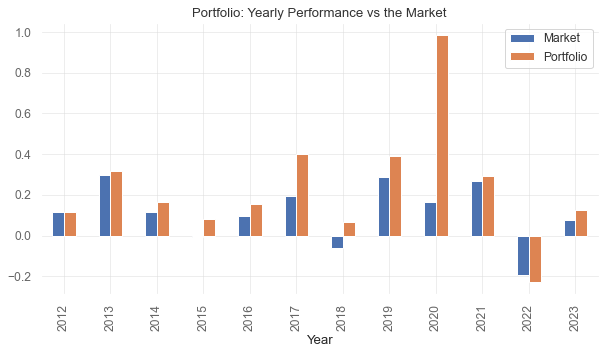

In [15]:
ret_eoy.set_index('Year').plot.bar(figsize =(10,5), title = 'Portfolio: Yearly Performance vs the Market')

## Full Report 

                           Strategy    Benchmark
-------------------------  ----------  -----------
Start Period               2012-01-04  2012-01-04
End Period                 2023-04-14  2023-04-14
Risk-Free Rate             0.0%        0.0%
Time in Market             100.0%      100.0%

Cumulative Return          870.53%     224.0%
CAGR﹪                     22.32%      10.98%

Sharpe                     1.33        0.69
Smart Sharpe               1.32        0.69
Sortino                    1.93        0.97
Smart Sortino              1.91        0.96
Sortino/√2                 1.36        0.69
Smart Sortino/√2           1.35        0.68
Omega                      1.28        1.28

Max Drawdown               -30.39%     -33.92%
Longest DD Days            508         465
Volatility (ann.)          16.19%      17.18%
R^2                        0.73        0.73
Calmar                     0.73        0.32
Skew                       -0.3        -0.52
Kurtosis                   7.63        

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2021-11-22,2022-06-16,2023-04-14,508,-30.388708,-29.215040
2,2020-02-20,2020-03-23,2020-05-07,77,-24.181896,-24.081500
3,2018-10-02,2018-12-24,2019-02-22,143,-15.033124,-13.318121
4,2015-08-06,2016-02-11,2016-04-13,251,-14.529939,-14.048048
5,2021-02-16,2021-03-08,2021-06-17,121,-12.952955,-11.220188


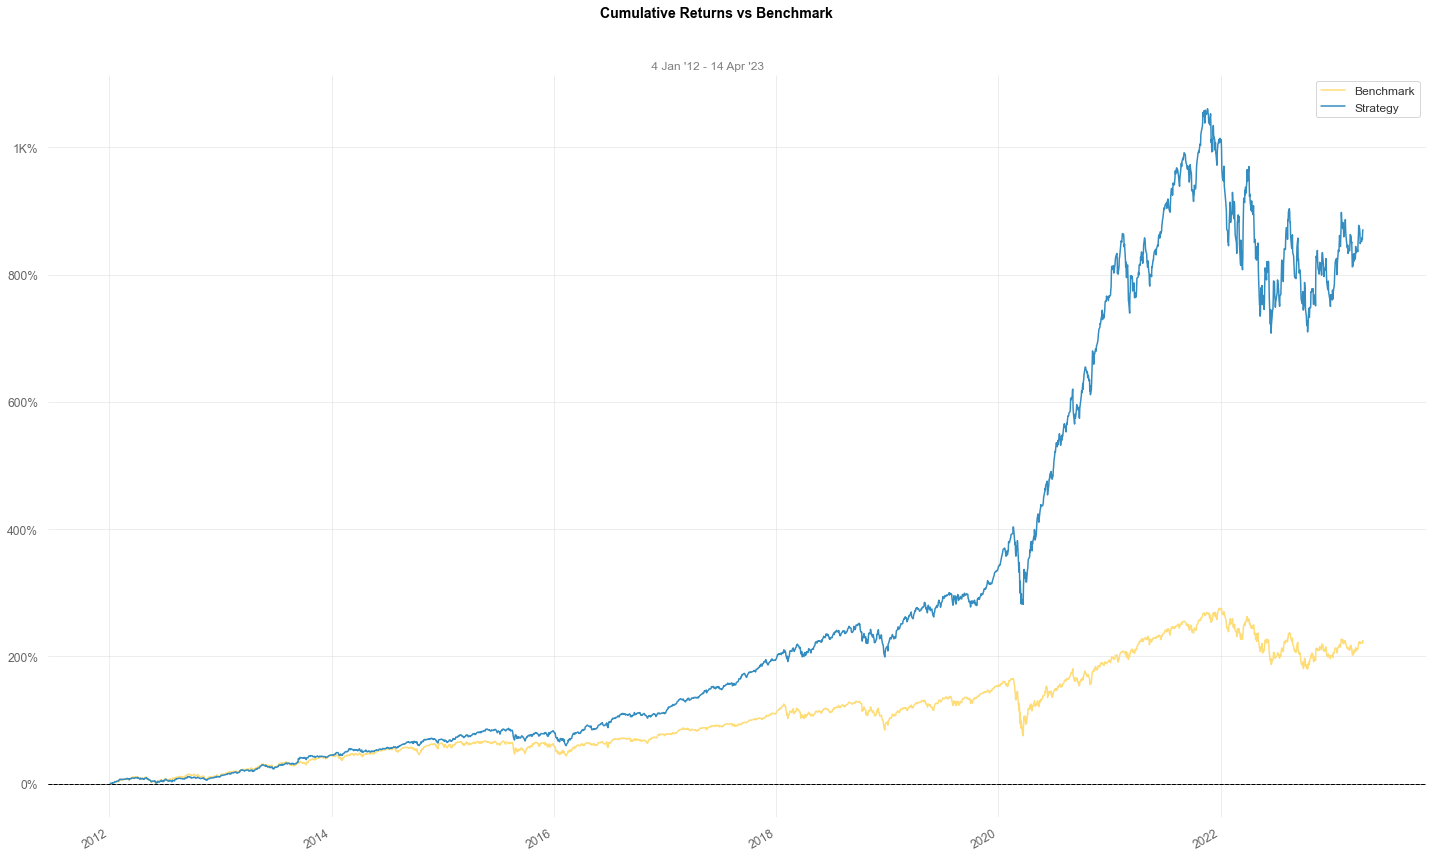

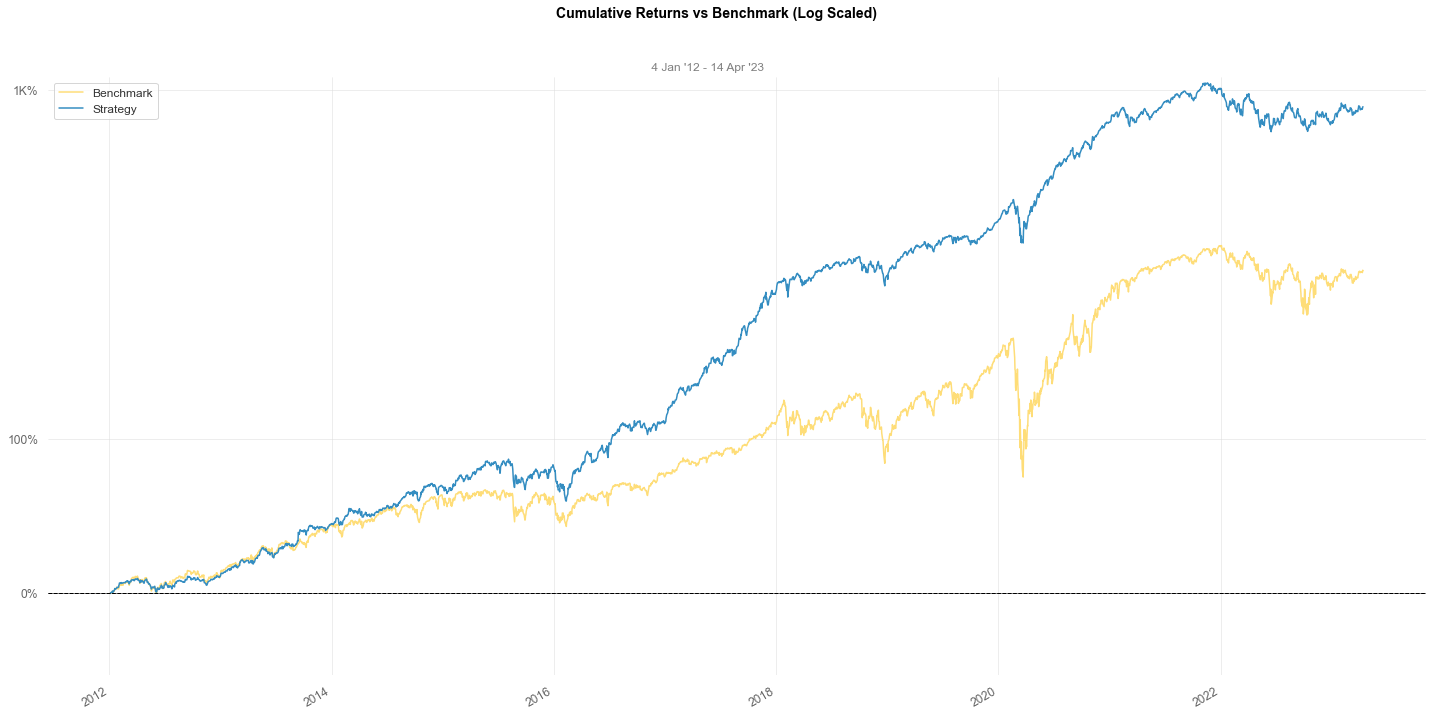

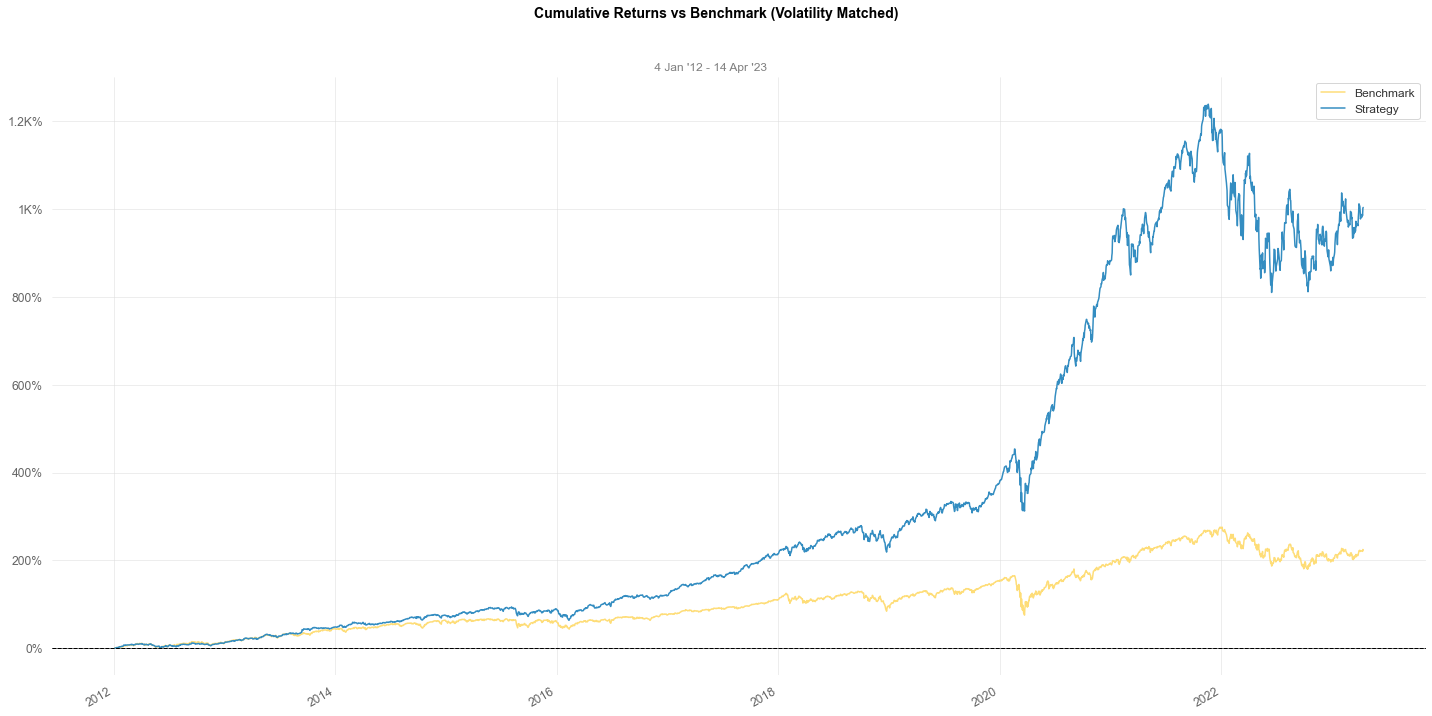

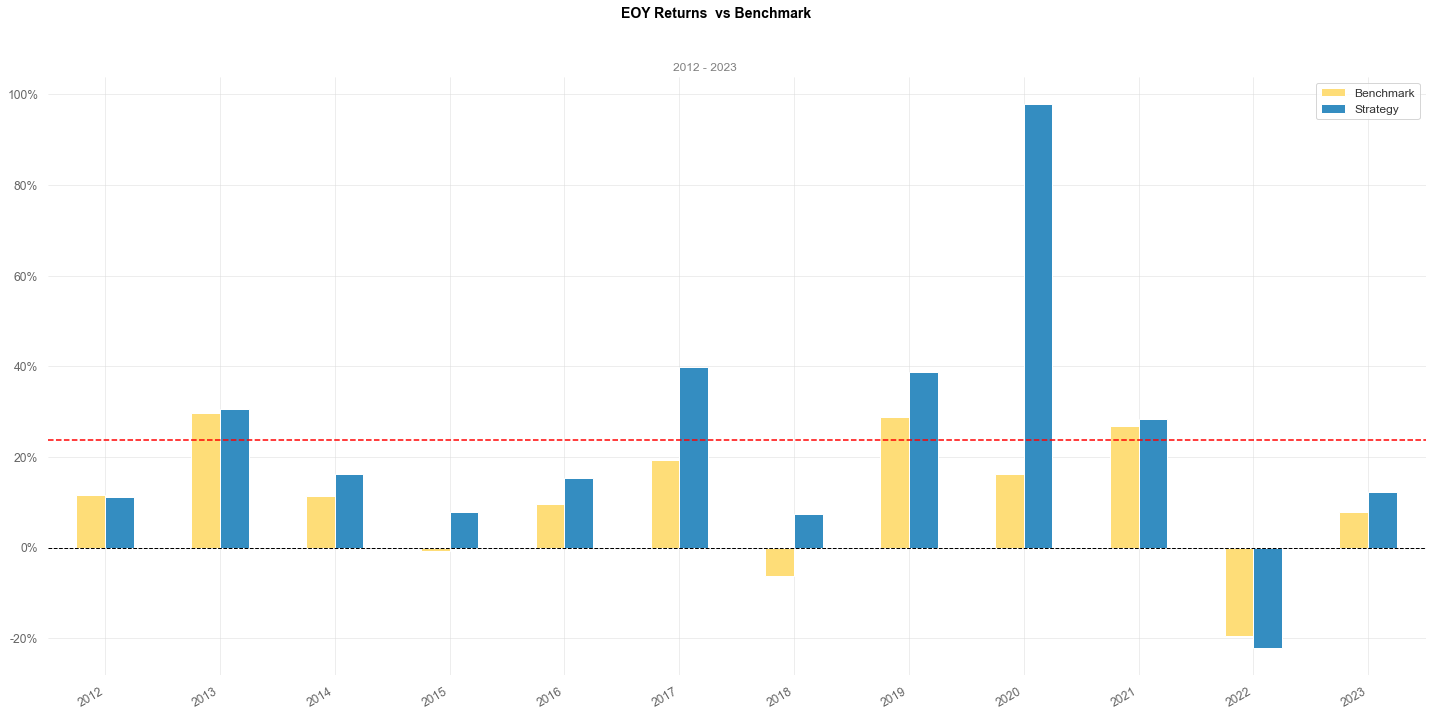

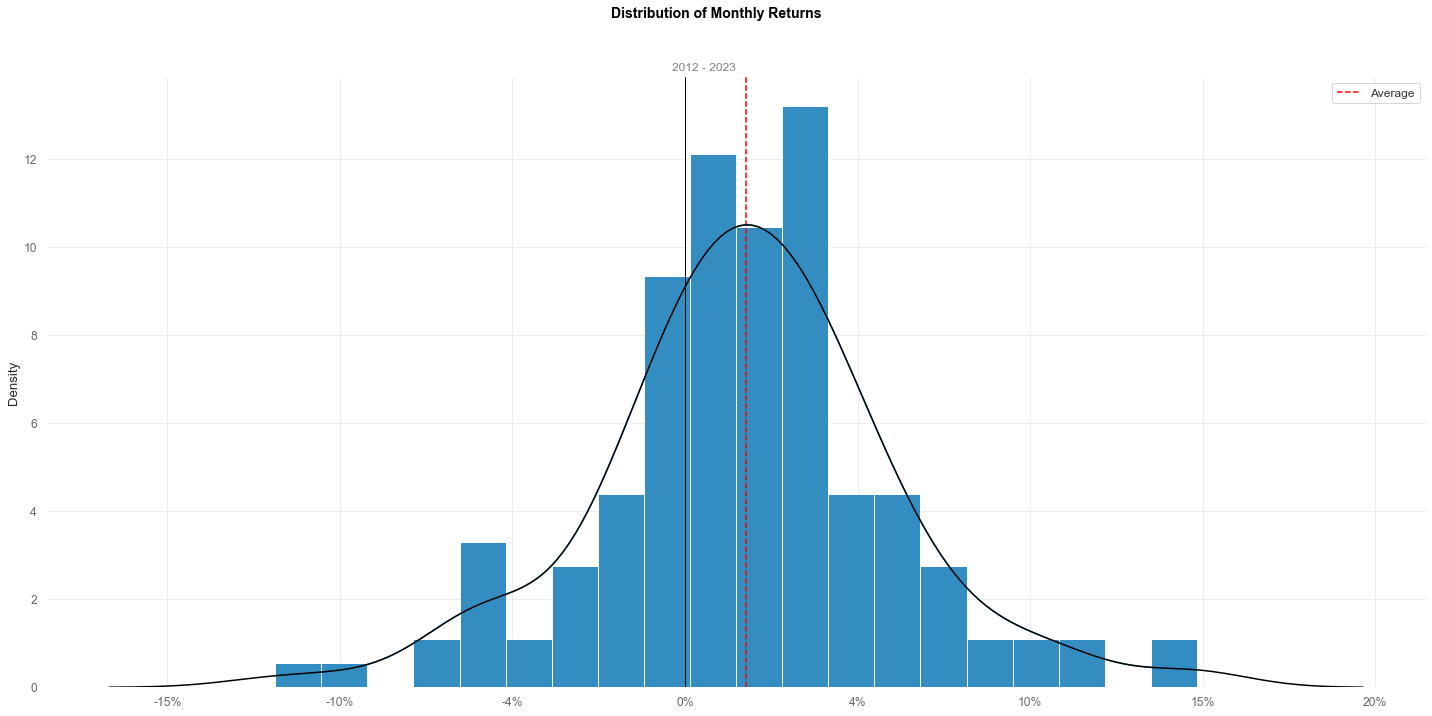

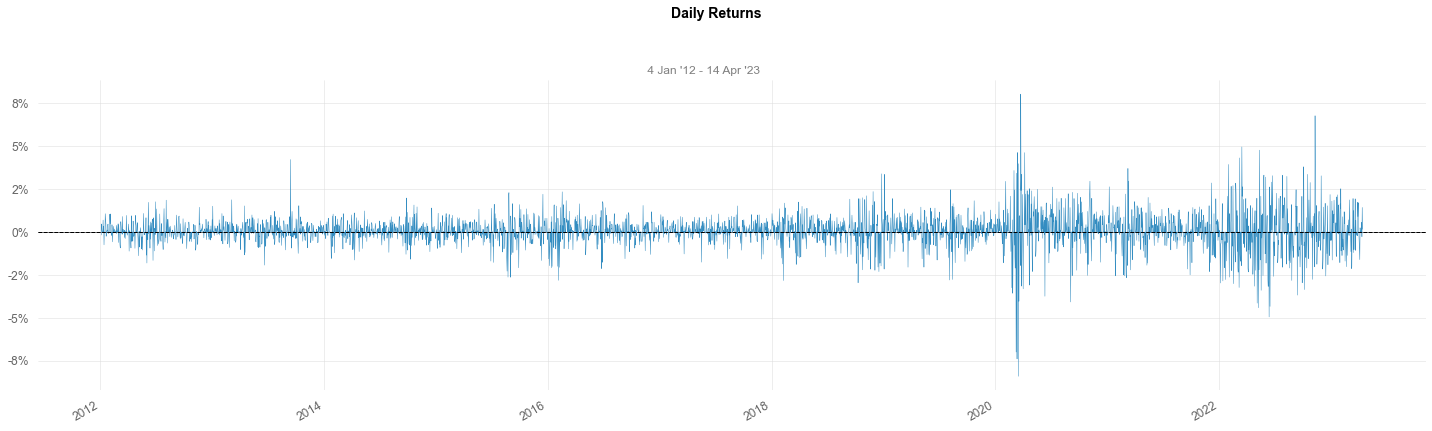

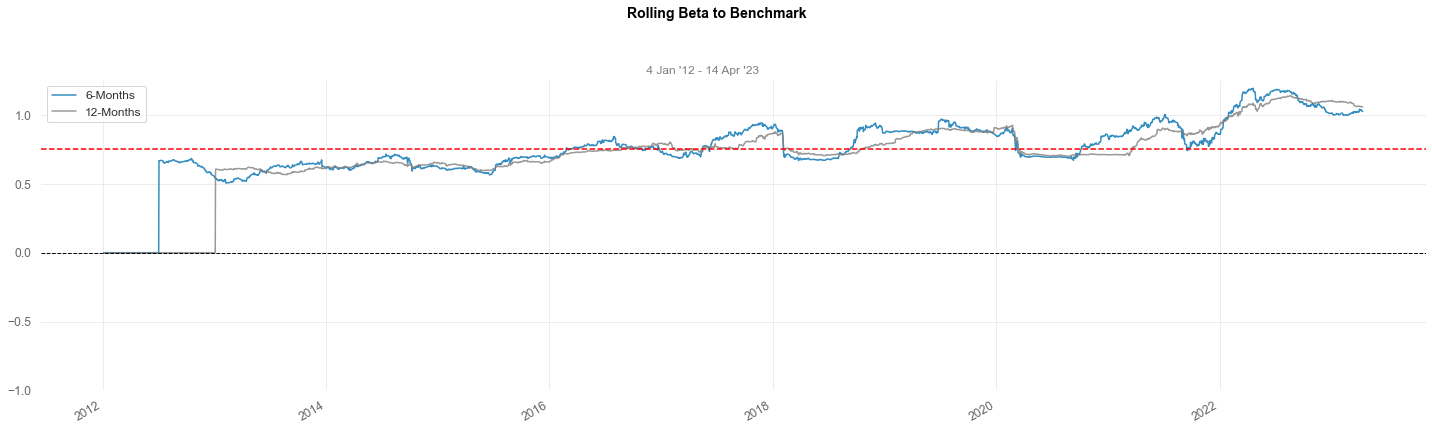

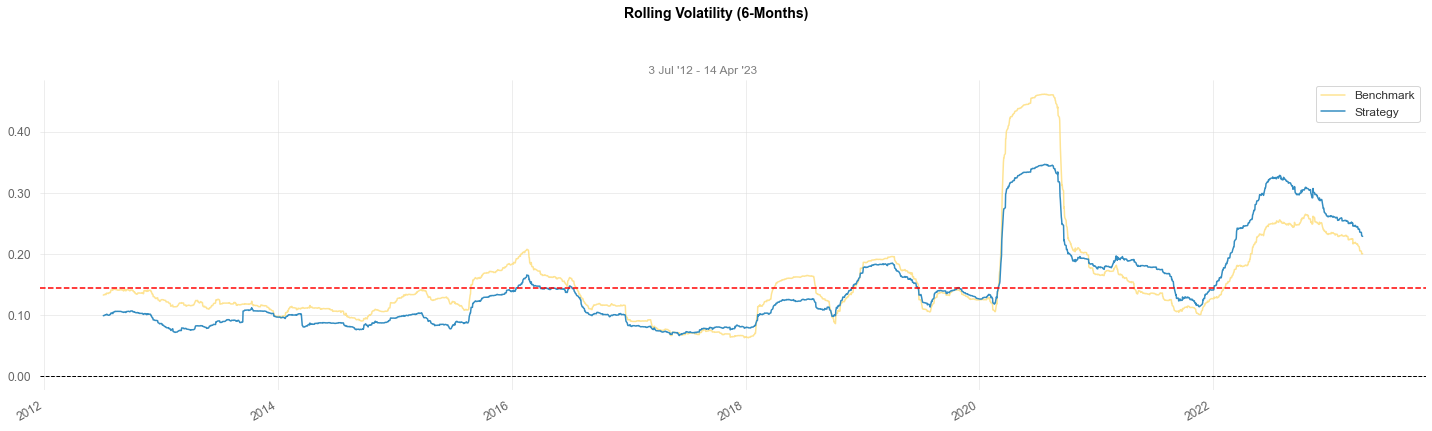

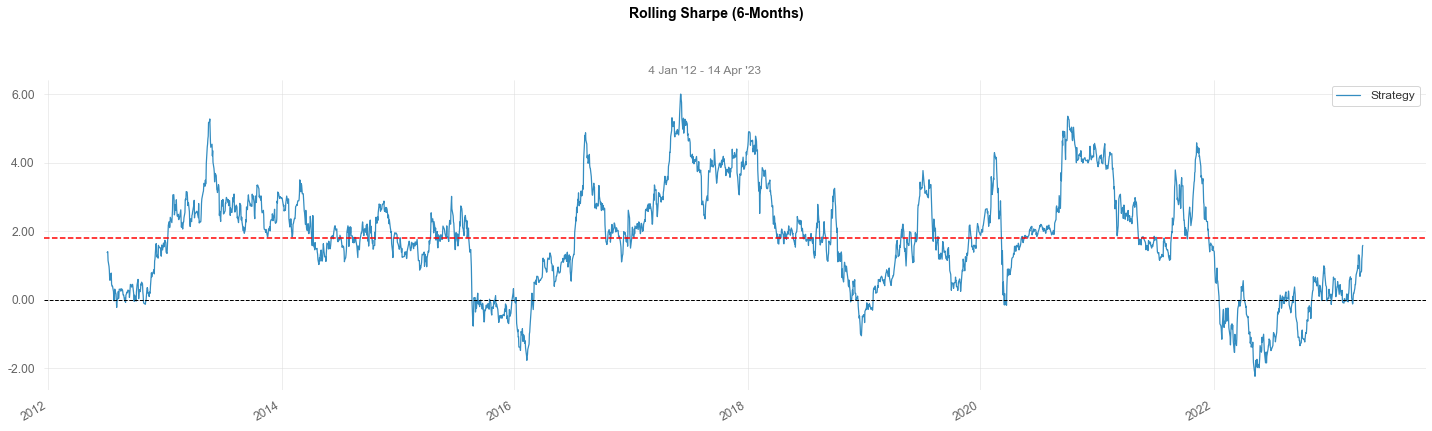

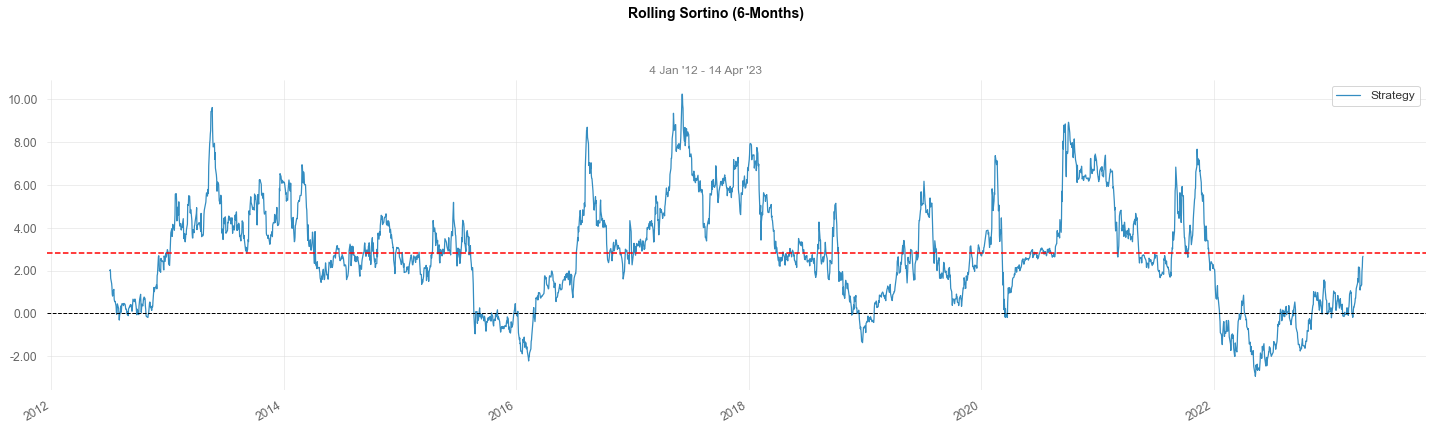

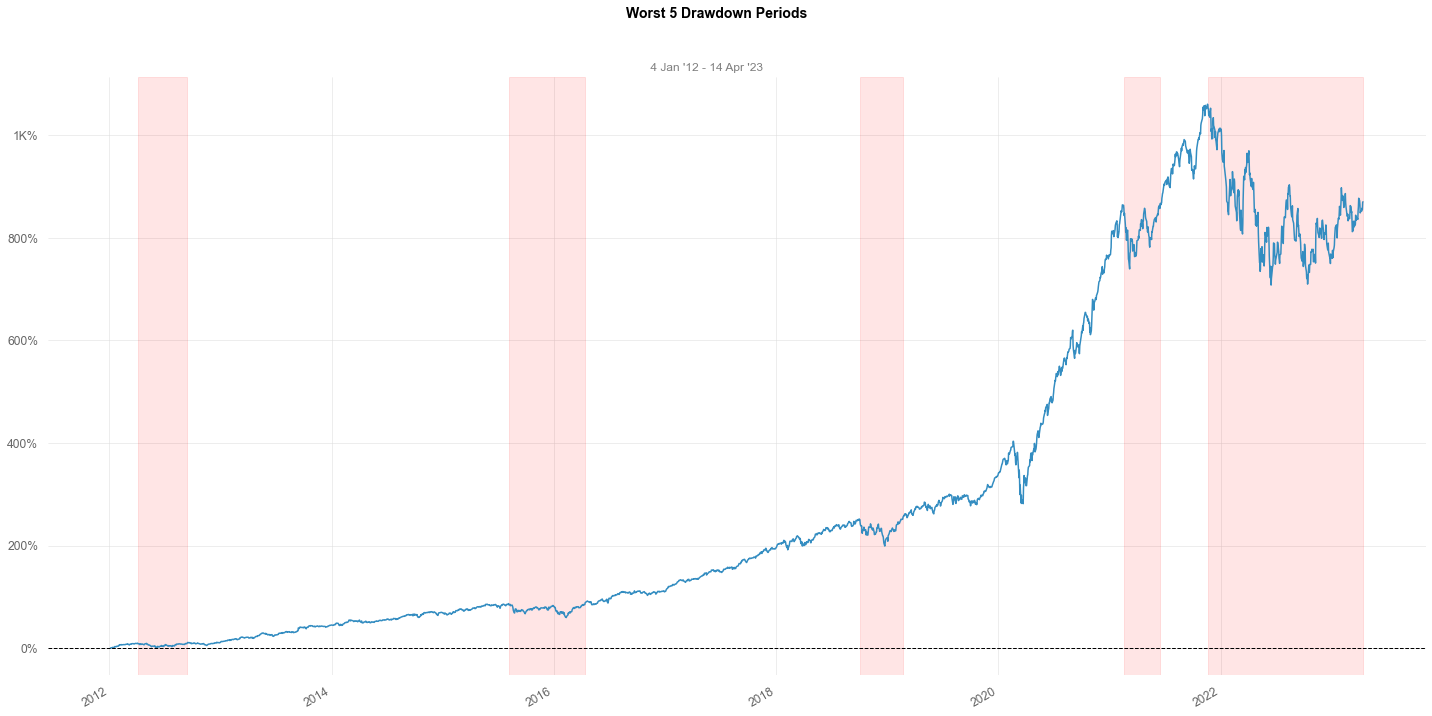

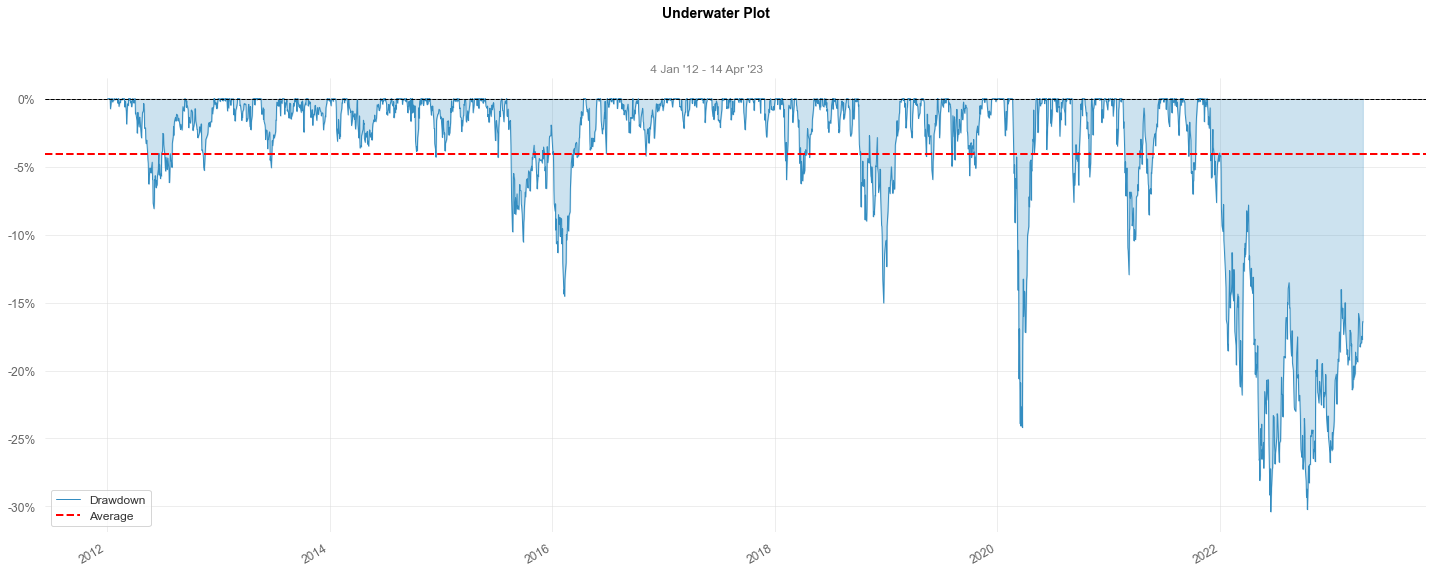

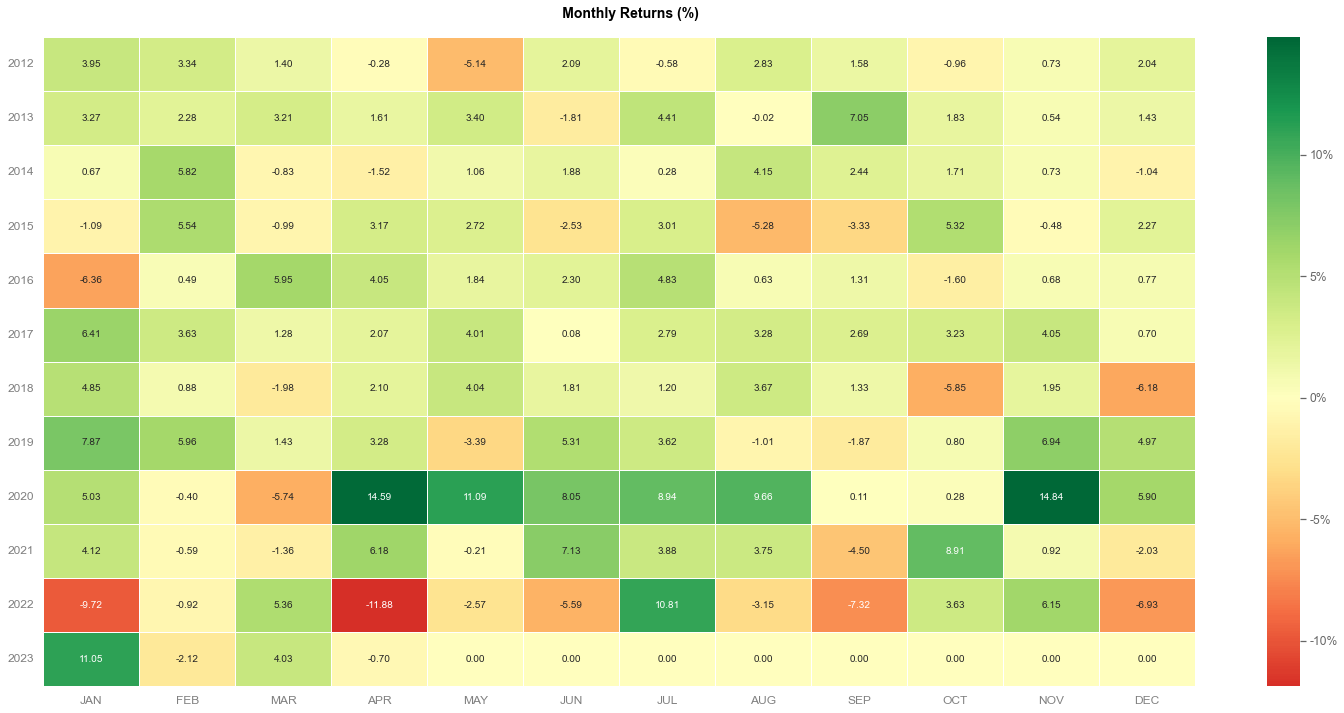

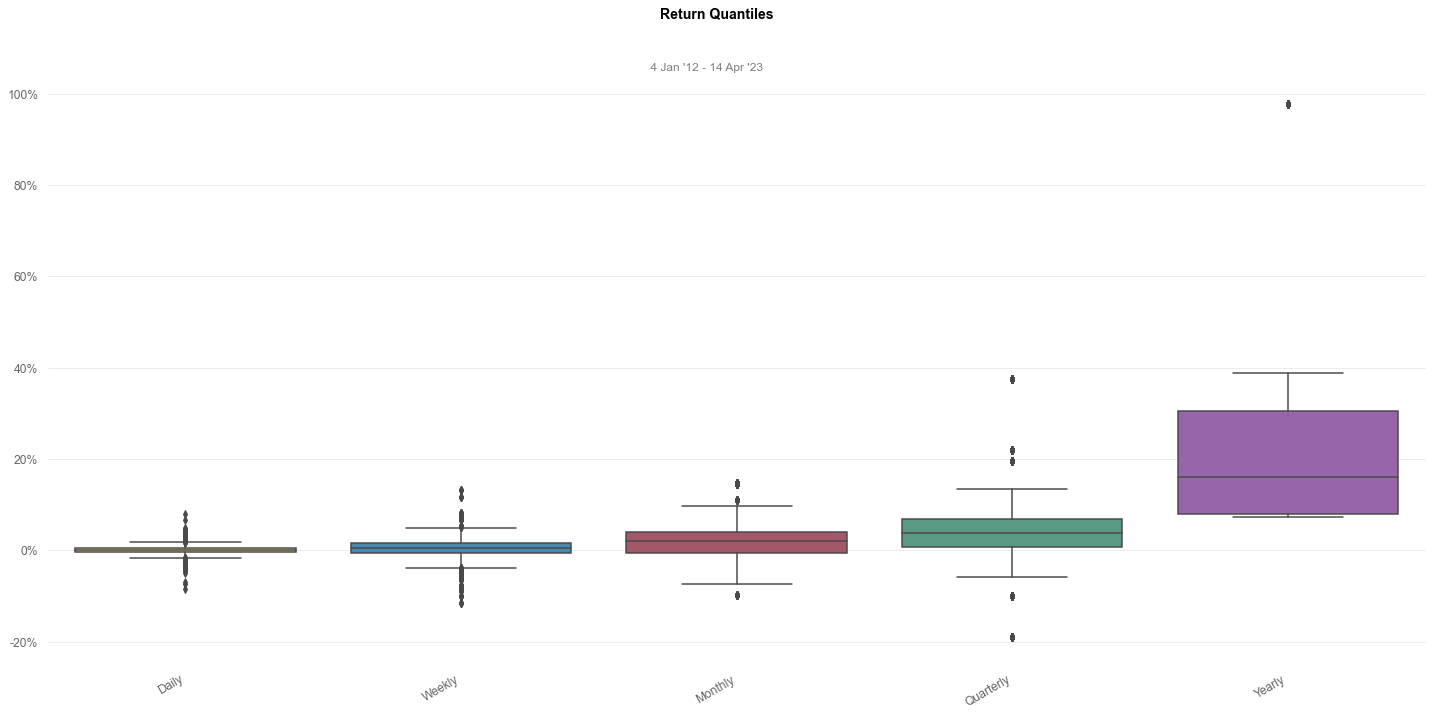

In [12]:
qs.reports.full(ret['myPortfolio'], ret['Market'], figsize=(10, 5))